In [1]:
import pandas as pd
import pickle
import numpy as np
import os

output_base = 'output/data' 
df_raw = pickle.load(open(f'{output_base}/df_raw.pkl', "rb"))
df_ML = pickle.load(open(f'{output_base}/df_ML.pkl', "rb"))
df_ML_unscaled = pickle.load(open(f'{output_base}/df_ML_unscaled.pkl', "rb"))
feature_names = pickle.load(open(f'{output_base}/feature_names.pkl', "rb"))
ML_feature_names = pickle.load(open(f'{output_base}/ML_feature_names.pkl', "rb"))

figure_path = 'output/figures'
if not os.path.exists(figure_path):
    os.makedirs(figure_path)

In [9]:

from collections import OrderedDict

feature_name_map = OrderedDict([
    ('max_force', 'Max Force'),
    ('force_variation_rate', 'Force Variation Rate'),
    ('avg_first_5', 'Average First 5 Samples'),
    ('avg_last_5', 'Average Last 5 Samples'),
    ('pk_sharp_max', 'Max Peak Sharpness'),
    ('pk_sharp_mean', 'Mean Peak Sharpness'),
    ('pk_sharp_min', 'Min Peak Sharpness'),
    ('skewness', 'Skewness'),
    ('kurtosis', 'Kurtosis'),
    ('total_press_duration', 'Press Duration'),
    ('pk_num', 'Peak Number'),
    ('pk_widths_max', 'Max Peak Width'),
    ('pk_widths_mean', 'Mean Peak Width'),
    ('pk_widths_min', 'Min Peak Width')
])

ordered_features = list(feature_name_map.keys())
ordered_features


['max_force',
 'force_variation_rate',
 'avg_first_5',
 'avg_last_5',
 'pk_sharp_max',
 'pk_sharp_mean',
 'pk_sharp_min',
 'skewness',
 'kurtosis',
 'total_press_duration',
 'pk_num',
 'pk_widths_max',
 'pk_widths_mean',
 'pk_widths_min']

In [10]:
# distribution of sex
df_raw2 = df_raw.drop_duplicates(subset=['id'])
rat_gender_count = df_raw2.sex.value_counts(dropna=False).to_dict()

print(f"females: {rat_gender_count.get(0, 0)}")
print(f"males: {rat_gender_count.get(1, 0)}")
print(f"total: {len(df_raw2)}")

females: 11
males: 30
total: 41


In [3]:
# number of sessions
session_num = df_raw.groupby('category').count()['id'].to_dict()
print(f"number of sessions by group: {session_num}")

# session duration
df_raw['raw_data_len'] = df_raw['raw_data'].apply(lambda x: len(x) / 100/60)
df_raw.groupby('category')['raw_data_len'].mean()


number of sessions by group: {'EXT': 60, 'FR1': 82}


category
EXT    61.828944
FR1    14.630154
Name: raw_data_len, dtype: float64

# Descriptive table for features

In [11]:
import pandas as pd
from scipy.stats import ttest_ind


results = []

for feat in ordered_features:
    fr1 = df_ML_unscaled[df_ML_unscaled['category'] == 'FR1'][feat].dropna()
    ext = df_ML_unscaled[df_ML_unscaled['category'] == 'EXT'][feat].dropna()
    
    # Descriptive stats
    fr1_mean, fr1_sd = fr1.mean(), fr1.std()
    ext_mean, ext_sd = ext.mean(), ext.std()
    
    # Welch’s t-test
    t_stat, p_val = ttest_ind(fr1, ext, equal_var=False)
    
    results.append({
        'Feature': feature_name_map.get(feat, feat),
        'FR1 (Mean ± SD)': f"{fr1_mean:.2f} ± {fr1_sd:.2f}",
        'EXT (Mean ± SD)': f"{ext_mean:.2f} ± {ext_sd:.2f}",
        'P-value': "<0.001" if p_val < 0.001 else f"{p_val:.3f}"
    })

# Create final table
df_table = pd.DataFrame(results)

# Display in notebook
display(df_table)

# Optional: export to LaTeX
latex_table = df_table.to_latex(index=False, escape=False)
print(latex_table)

,Feature,FR1 (Mean ± SD),EXT (Mean ± SD),P-value
0,Max Force,44.11 ± 42.98,43.08 ± 31.69,0.036
1,Force Variation Rate,7.82 ± 11.52,7.09 ± 8.24,<0.001
2,Average First 5 Samples,14.49 ± 5.59,15.18 ± 5.69,<0.001
3,Average Last 5 Samples,13.35 ± 15.97,12.94 ± 12.41,0.027
4,Max Peak Sharpness,2.04 ± 3.45,1.86 ± 2.96,<0.001
5,Mean Peak Sharpness,1.90 ± 3.39,1.66 ± 2.85,<0.001
6,Min Peak Sharpness,1.78 ± 3.40,1.48 ± 2.84,<0.001
7,Skewness,-0.03 ± 0.67,-0.14 ± 0.71,<0.001
8,Kurtosis,-0.48 ± 1.09,-0.24 ± 1.22,<0.001
9,Press Duration,60.31 ± 51.04,75.64 ± 58.29,<0.001


\begin{tabular}{llll}
\toprule
Feature & FR1 (Mean ± SD) & EXT (Mean ± SD) & P-value \\
\midrule
Max Force & 44.11 ± 42.98 & 43.08 ± 31.69 & 0.036 \\
Force Variation Rate & 7.82 ± 11.52 & 7.09 ± 8.24 & <0.001 \\
Average First 5 Samples & 14.49 ± 5.59 & 15.18 ± 5.69 & <0.001 \\
Average Last 5 Samples & 13.35 ± 15.97 & 12.94 ± 12.41 & 0.027 \\
Max Peak Sharpness & 2.04 ± 3.45 & 1.86 ± 2.96 & <0.001 \\
Mean Peak Sharpness & 1.90 ± 3.39 & 1.66 ± 2.85 & <0.001 \\
Min Peak Sharpness & 1.78 ± 3.40 & 1.48 ± 2.84 & <0.001 \\
Skewness & -0.03 ± 0.67 & -0.14 ± 0.71 & <0.001 \\
Kurtosis & -0.48 ± 1.09 & -0.24 ± 1.22 & <0.001 \\
Press Duration & 60.31 ± 51.04 & 75.64 ± 58.29 & <0.001 \\
Peak Number & 1.25 ± 0.94 & 1.48 ± 1.04 & <0.001 \\
Max Peak Width & 21.70 ± 16.48 & 28.41 ± 22.05 & <0.001 \\
Mean Peak Width & 19.13 ± 12.59 & 23.09 ± 15.39 & <0.001 \\
Min Peak Width & 17.00 ± 12.37 & 18.69 ± 14.95 & <0.001 \\
\bottomrule
\end{tabular}



# Headmap

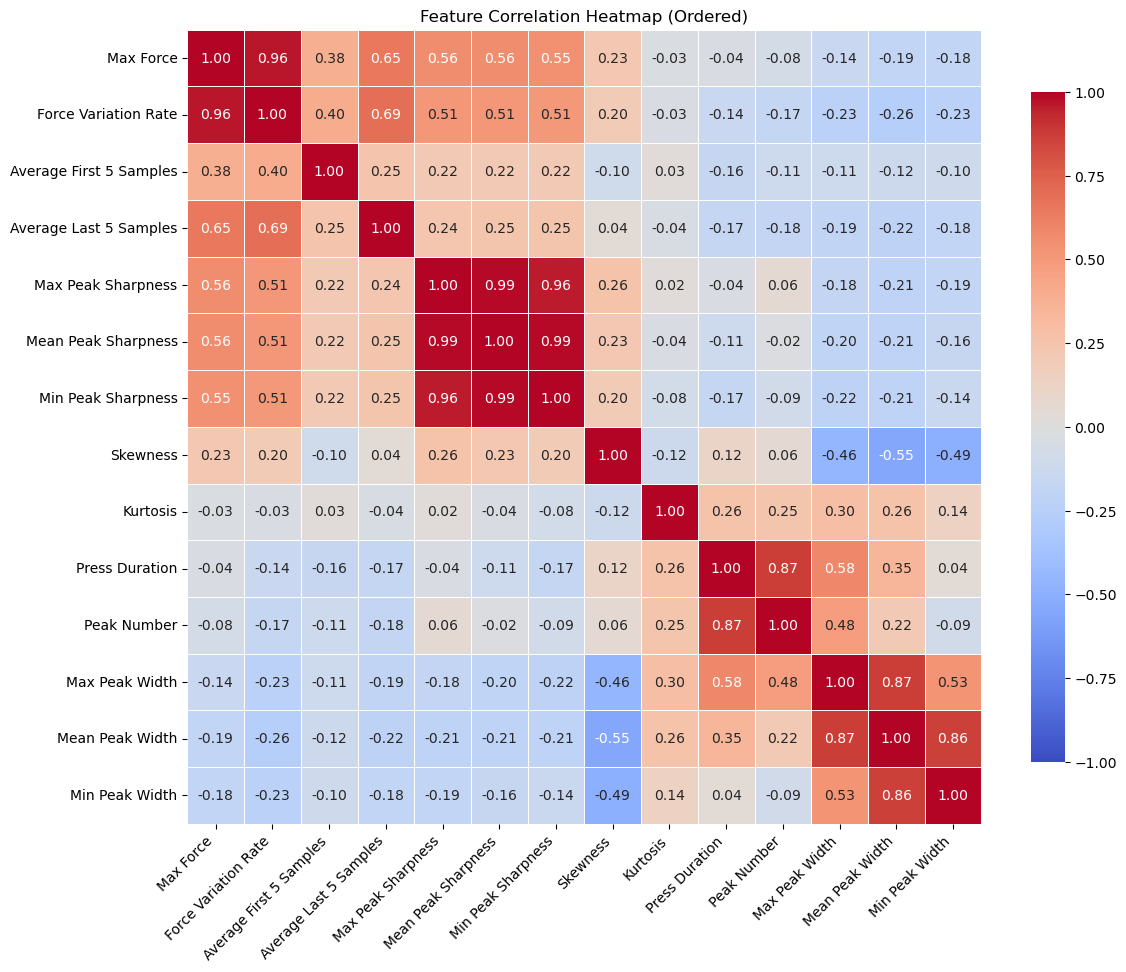

In [12]:
# Select + reorder + rename
df_features = df_ML_unscaled[ordered_features].copy()
df_features.rename(columns=feature_name_map, inplace=True)

# Correlation
corr_matrix = df_features.corr()

# Plot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',   
    vmin=-1, vmax=1,   
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Feature Correlation Heatmap (Ordered)")
plt.tight_layout()
plt.savefig(f"{figure_path}/correlation.png", dpi=300, bbox_inches='tight')
plt.show()

# Model Evaluation (outdated, see models.ipynb)

In [14]:
import os, pickle
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score
from pauc import ROC

df_ML_train = pickle.load(open(os.path.join(output_base, "df_ML_train.pkl"), "rb"))
df_ML_test = pickle.load(open(os.path.join(output_base, "df_ML_test.pkl"), "rb"))
feature_names = pickle.load(open(os.path.join(output_base, "feature_names.pkl"), "rb"))


x_train = df_ML_train.loc[:, ML_feature_names]
y_train = df_ML_train.loc[:, 'label'].values
x_test = df_ML_test.loc[:, ML_feature_names]
y_test = df_ML_test.loc[:, 'label'].values

print(ML_feature_names)
print(f"{len(x_train)} training samples, {len(x_test)} testing samples")


['total_press_duration', 'max_force', 'pk_widths_max', 'pk_widths_mean', 'pk_widths_min', 'pk_sharp_mean', 'pk_sharp_min', 'skewness', 'kurtosis', 'avg_first_5', 'avg_last_5', 'sex']
19749 training samples, 3404 testing samples


In [15]:

from sklearn.metrics import f1_score, recall_score, precision_score

def calc_metrics(y_true, y_prob):
    thresholds = np.unique(y_prob)
    best_threshold = 0.5
    best_f1 = -1.0

    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred_t, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = float(t)

    y_pred_t = (y_prob >= best_threshold).astype(int)
    f1 = f1_score(y_true, y_pred_t, zero_division=0)
    recall = recall_score(y_true, y_pred_t, zero_division=0)
    precision = precision_score(y_true, y_pred_t, zero_division=0)
    auc = roc_auc_score(y_true, y_prob)

    return {
        "threshold": round(best_threshold, 3),
        "f1_score": round(f1, 3),
        "recall": round(recall, 3),
        "precision": round(precision, 3),
        "auc": round(auc, 3),
    }

## Logistic

In [16]:
feature_names

['total_press_duration',
 'max_force',
 'pk_num',
 'pk_widths_max',
 'pk_widths_mean',
 'pk_widths_min',
 'pk_sharp_max',
 'pk_sharp_mean',
 'pk_sharp_min',
 'skewness',
 'kurtosis',
 'force_variation_rate',
 'avg_first_5',
 'avg_last_5',
 'sex']

In [17]:
x_train.columns

Index(['total_press_duration', 'max_force', 'pk_widths_max', 'pk_widths_mean',
       'pk_widths_min', 'pk_sharp_mean', 'pk_sharp_min', 'skewness',
       'kurtosis', 'avg_first_5', 'avg_last_5', 'sex'],
      dtype='object')

In [18]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from confidenceinterval import roc_auc_score

vars = [
    'total_press_duration', 'max_force', 'pk_widths_max', 'pk_widths_mean',
    'pk_widths_min', 'pk_sharp_mean', 'pk_sharp_min', 'skewness',
    'kurtosis', 'avg_first_5', 'avg_last_5'
]

result = []


df_ML_train = pickle.load(open(os.path.join(output_base, "df_ML_train.pkl"), "rb"))
df_ML_test = pickle.load(open(os.path.join(output_base, "df_ML_test.pkl"), "rb"))
feature_names = pickle.load(open(os.path.join(output_base, "feature_names.pkl"), "rb"))

df_ML_train['max_force'] = (
    df_ML_train['max_force']
    - df_ML_train.groupby('id')['max_force'].transform('mean')
)


df_ML_test['max_force'] = (
    df_ML_test['max_force']
    - df_ML_test.groupby('id')['max_force'].transform('mean')
)



x_train = df_ML_train.loc[:, ML_feature_names]
y_train = df_ML_train.loc[:, 'label'].values
x_test = df_ML_test.loc[:, ML_feature_names]
y_test = df_ML_test.loc[:, 'label'].values


for feature in vars:
    X_train_feat = x_train.loc[:, [feature, 'sex']]
    X_test_feat = x_test.loc[:, [feature, 'sex']]

    model = LogisticRegression()
    model.fit(X_train_feat, y_train)

    y_pred_prob = model.predict_proba(X_test_feat)[:, 1]

    auc, ci = roc_auc_score(y_test, y_pred_prob, confidence_level=0.95)
    ci_lower, ci_upper = ci

    result.append((feature, auc, ci_lower, ci_upper))

df_result = pd.DataFrame(result, columns=['Feature', 'AUC', 'CI_lower', 'CI_upper'])

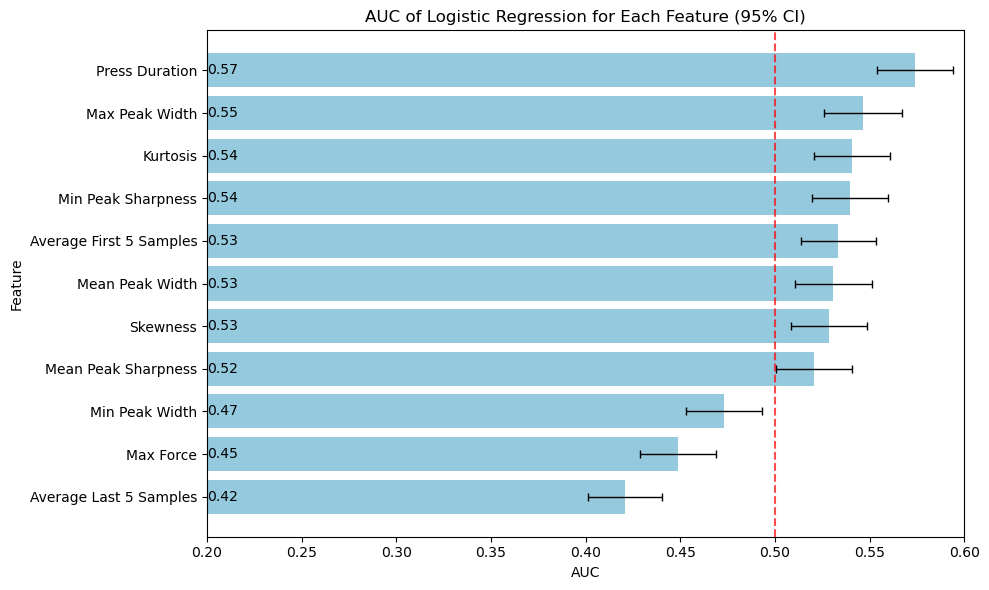

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



df_result2 = df_result.copy()
df_result2['Feature'] = df_result2['Feature'].map(feature_name_map)

# sort for cleaner plot
df_result2 = df_result2.sort_values('AUC', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df_result2, x='AUC', y='Feature', color='skyblue')

# CI error bars
xerr = np.vstack([
    df_result2['AUC'] - df_result2['CI_lower'],
    df_result2['CI_upper'] - df_result2['AUC']
])

ax.errorbar(
    df_result2['AUC'],
    np.arange(len(df_result2)),
    xerr=xerr,
    fmt='none',
    ecolor='black',
    capsize=3,
    linewidth=1
)

#  Add AUC labels inside bars
for i, auc in enumerate(df_result2['AUC']):
    ax.text(
        0.2,                 # small offset from x=0
        i,
        f"{auc:.2f}",
        va='center',
        ha='left',            # anchor text to the left
        color='black',
        fontsize=10
    )

plt.title("AUC of Logistic Regression for Each Feature (95% CI)")
plt.axvline(0.5, linestyle='--', color='red', alpha=0.7)  # optional baseline
ax.set_xlim(0.2, 0.6)
plt.tight_layout()
plt.savefig(f"{figure_path}/feature_auc.png", dpi=300, bbox_inches='tight')
plt.show()

In [20]:
from sklearn.linear_model import LogisticRegression
C = 0.009
lg = LogisticRegression(max_iter=10000, l1_ratio=1.0, C=C, solver='liblinear')
lg.fit(x_train, y_train)
y_pred = lg.predict_proba(x_test)[:, 1]
df_ML_test["lg_prob"] = y_pred
LG_metrics = calc_metrics(y_test, y_pred)
print(LG_metrics)

TypeError: type tuple doesn't define __round__ method

In [ ]:
# coefficient
coef_df = pd.DataFrame({
    'Feature': ML_feature_names,
    'Coefficient': lg.coef_[0]
})
coef_df

,Feature,Coefficient
0,total_press_duration,0.143802
1,max_force,-0.024914
2,pk_widths_max,0.218718
3,pk_widths_mean,0.000000
4,pk_widths_min,0.000000
5,pk_sharp_mean,0.000000
6,pk_sharp_min,-0.048785
7,skewness,0.000000
8,kurtosis,0.077681
9,avg_first_5,0.152402


# GB

In [21]:
import xgboost as xgb

gb = xgb.XGBClassifier(
    max_depth=2,
    min_child_weight=8,
    subsample=0.9,
    colsample_bytree=1,
    reg_lambda=10,
    tree_method="hist",
    random_state=42
)


gb.fit(x_train, y_train)
y_pred = gb.predict_proba(x_test)[:, 1]
df_ML_test["gb_prob"] = y_pred
GB_metrics = calc_metrics(y_test, y_pred)
print(GB_metrics)


TypeError: type tuple doesn't define __round__ method

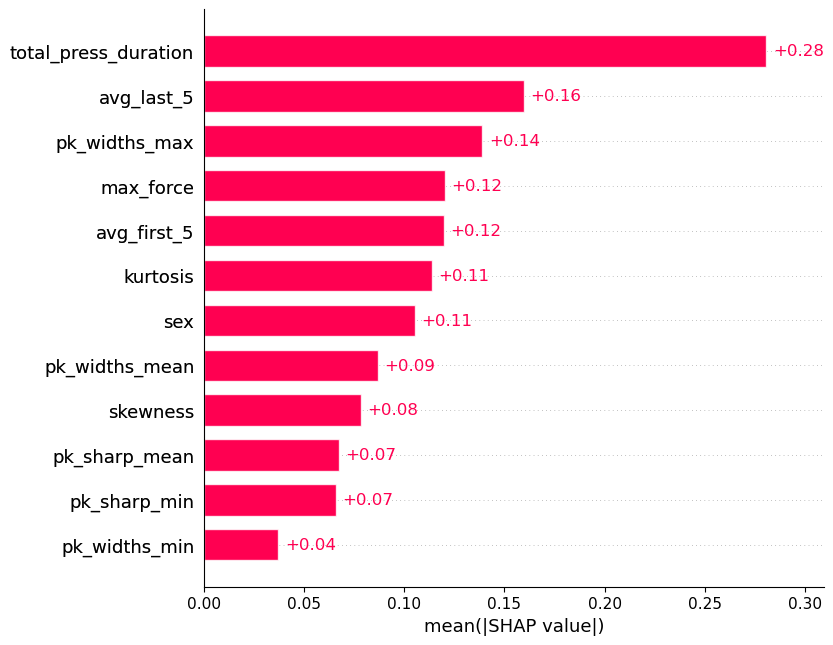

In [ ]:
import shap
import matplotlib.pyplot as plt

expl_gb = shap.Explainer(gb, x_train)
shap_values = expl_gb(x_test)

shap.plots.bar(shap_values, max_display=30)
plt.show()

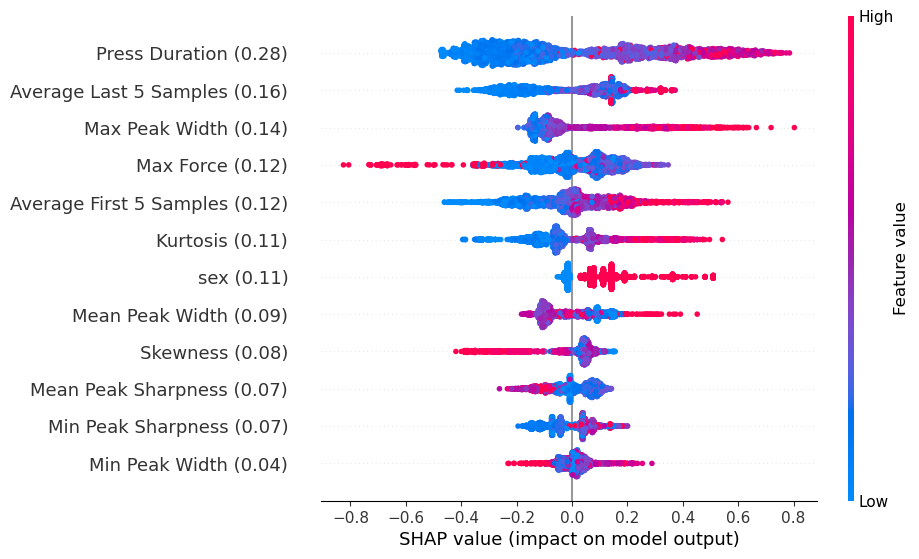

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

shap_values = expl_gb(x_test)
mean_shap = np.abs(shap_values.values).mean(axis=0)

shap_values.feature_names = [
    f"{feature_name_map.get(name, name)} ({mean_shap[i]:.2f})"
    for i, name in enumerate(x_test.columns)
]

plt.figure(figsize=(8, 6))
shap.plots.beeswarm(shap_values, max_display=30, show=False)

fig = plt.gcf()
fig.savefig(f"{figure_path}/shap_plot_GB.png", dpi=300, bbox_inches="tight")
plt.show()

# GRU

In [ ]:
from modules.nn_models import GRUModel
from modules.nn_train import dataframe_to_tensors
import torch

gru = GRUModel(input_size=1, hidden_size=256, num_layers=4, feature_size=0)

# load output/gru_models/vgysgbiu/best_model.pt
gru.load_state_dict(torch.load(f"output/gru_models/vgysgbiu/best_model.pt"))


device = "cpu"
nn_test = df_ML_test[['label', 'data']]
nn_test_x, nn_test_y, nn_test_lengths = dataframe_to_tensors(nn_test, device=device)
gru.eval()
with torch.no_grad():
    y_pred_tensor = gru(nn_test_x, nn_test_lengths)
    y_pred = y_pred_tensor.squeeze().numpy()
    # sigmoid to convert logits to probabilities
    y_pred = 1 / (1 + np.exp(-y_pred)) 

df_ML_test["gru_prob"] = y_pred
gru_metrics = calc_metrics(y_test, y_pred[:,1])
print(gru_metrics)

{'threshold': 0.38, 'f1_score': 0.578, 'recall': 0.909, 'precision': 0.423, 'auc': 0.651}


# comparing FR1 vs EXT

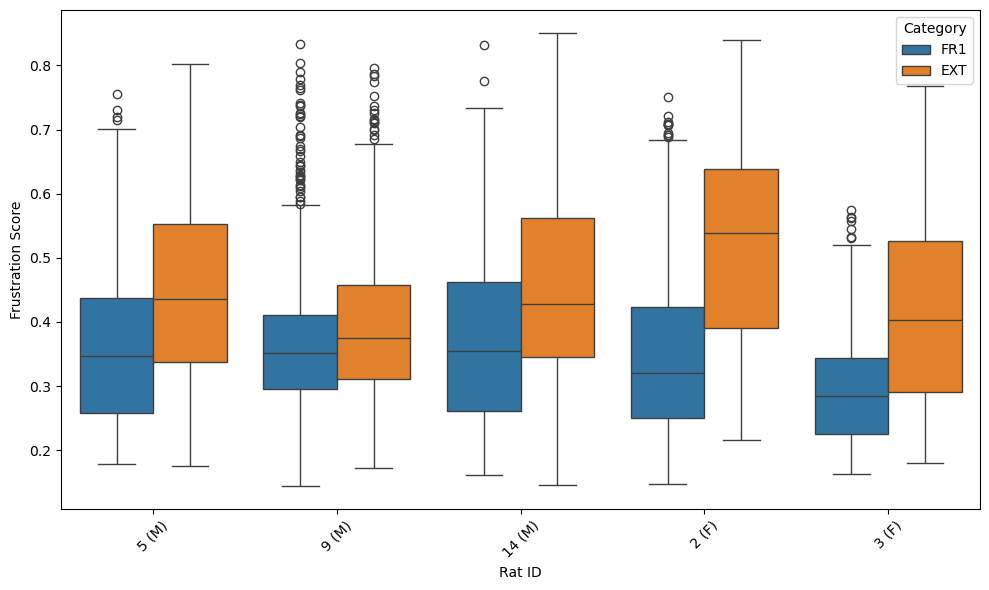

In [256]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df_ML2 = df_ML_test.copy()
df_ML2['id2'] = [i if i<1000 else i-1000 for i in df_ML2['id']]
# combine with sex
df_ML2['id2'] = df_ML2.apply(lambda row: f"{row['id2']} ({'M' if row['sex'] ==1 else 'F'})", axis=1)
sns.boxplot(
    data=df_ML2,
    x='id2',          # group by rat ID
    y='gb_prob',     # probability values
    hue='category'   # FR1 vs EXT
)

plt.xlabel('Rat ID')
plt.ylabel('Frustration Score')
plt.legend(title='Category')
plt.xticks(rotation=45)

plt.tight_layout()

fig = plt.gcf()
fig.savefig(f"{figure_path}/boxplot_holdout.png", dpi=300, bbox_inches="tight")
plt.show()

In [259]:
# Step 1: SD per rat per category
sd_per_rat = (
    df_ML_test
    .groupby(['id', 'category'], observed=True)['gb_prob']
    .std()
    .reset_index(name='sd')
)

# Step 2: Average SD across rats for each category
avg_sd_by_category = (
    sd_per_rat
    .groupby('category', observed=True)['sd']
    .mean()
    .reset_index(name='avg_sd')
)

print(avg_sd_by_category)

  category    avg_sd
0      FR1  0.121069
1      EXT  0.145525


In [ ]:
df_ML_test[['id', 'category', 'gb_prob']]

,index,id,category,data,total_press_duration,max_force,pk_num,pk_widths_max,pk_widths_mean,pk_widths_min,...,pk_sharp_mean,pk_sharp_min,skewness,kurtosis,force_variation_rate,avg_first_5,avg_last_5,sex,label,gb_prob
0,515,5,EXT,"[6.348, 8.789, 12.207, 15.625, 18.066, 19.775,...",-0.001428,-0.599681,0.672359,-0.239313,-0.242940,-0.207997,...,-0.387250,-0.458363,1.275049,0.062637,-0.396438,-0.451444,-0.352215,1,1,0.410194
1,516,5,EXT,"[5.615, 7.568, 9.521, 11.475, 13.184, 14.893, ...",-0.350778,-0.393729,0.672359,-0.296786,-0.485691,-0.627222,...,-0.089754,-0.331706,1.013745,0.227199,-0.255720,-0.936399,-0.080449,1,1,0.329899
2,517,5,EXT,"[5.127, 8.545, 12.695, 17.334, 21.973, 25.879,...",-0.828837,-0.387491,-0.343706,-0.632974,-0.610460,-0.407506,...,0.011786,0.055416,-0.107488,-0.461091,-0.279157,-0.286895,-0.133486,1,1,0.389678
3,518,5,EXT,"[6.104, 10.498, 15.137, 19.531, 22.461, 23.438...",-0.479487,-0.387491,-0.343706,0.394906,0.803755,1.051245,...,-0.343730,-0.299688,-1.747134,0.810329,-0.279157,-0.001108,-0.189821,1,1,0.390836
4,519,5,EXT,"[5.127, 7.08, 9.033, 11.23, 13.428, 16.113, 19...",-0.405939,-0.474872,-0.343706,-0.233533,-0.060886,0.159375,...,-0.252402,-0.208465,0.545989,-0.693052,-0.419875,-0.988364,-0.428423,1,1,0.203114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3399,23148,1003,FR1,"[5.371, 6.836, 8.545, 10.498, 12.207, 13.672, ...",0.200828,-0.462371,-0.343706,0.577603,1.055120,1.310526,...,-0.387177,-0.343084,-0.112873,-0.586390,-0.419971,-1.074948,-0.464885,0,0,0.228548
3400,23149,1003,FR1,"[9.277, 15.381, 21.973, 28.564, 33.936, 37.598...",-0.222070,-0.119083,-0.343706,-0.821444,-0.869767,-0.674979,...,0.519850,0.562891,1.376311,0.256298,-0.091565,1.254554,-0.352201,0,0,0.362243
3401,23150,1003,FR1,"[7.813, 11.475, 15.137, 18.311, 21.24, 24.17, ...",4.356261,0.292846,3.720553,-0.149326,-0.409352,-0.596824,...,-0.073898,-0.290899,1.493860,0.344815,-0.185409,0.007582,-0.189834,0,0,0.407474
3402,23151,1003,FR1,"[5.127, 9.277, 14.648, 20.508, 25.879, 30.029,...",-0.314005,-0.218966,-0.343706,-0.329838,-0.193387,0.022701,...,-0.046280,-0.002582,0.926534,-0.737559,-0.161876,0.059476,-0.335640,0,0,0.231396


# Application

In [1]:
with open(f'{output_base}/df_app_ML.pkl', 'rb') as f:
    df_app_ML = pickle.load(f)
x_app = df_app_ML.loc[:, ML_feature_names]

NameError: name 'output_base' is not defined

In [233]:
df_app_ML.describe()

,id,total_press_duration,max_force,pk_num,pk_widths_max,pk_widths_mean,pk_widths_min,pk_sharp_max,pk_sharp_mean,pk_sharp_min,skewness,kurtosis,force_variation_rate,avg_first_5,avg_last_5,sex
count,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000,1068.000000
mean,12.240637,0.386728,-0.042539,0.152910,0.451478,0.313962,0.065090,-0.199704,-0.212882,-0.220039,0.010060,1.198595,0.248849,0.603133,-0.075840,0.467228
std,6.600329,1.182892,0.702554,1.132205,1.475170,1.416907,1.400664,0.694759,0.679281,0.678830,1.708706,3.641417,1.076509,1.212838,0.584887,0.499159
min,1.000000,-1.031093,-0.605919,-1.359770,-1.271565,-1.489069,-1.313784,-0.602004,-0.564602,-0.520303,-5.658999,-1.173009,-0.584030,-1.611867,-0.547745,0.000000
25%,8.000000,-0.461100,-0.424918,-0.343706,-0.725664,-0.762043,-0.798548,-0.478833,-0.451624,-0.435585,-1.085824,-0.445003,-0.302690,-0.245758,-0.362152,0.000000
50%,12.000000,0.145667,-0.218966,-0.343706,0.167297,0.157378,-0.457144,-0.352841,-0.349885,-0.370710,-0.068213,0.271431,-0.138439,0.388555,-0.211364,0.000000
75%,17.000000,0.881142,0.068155,0.672359,1.405520,1.101605,0.632349,-0.144834,-0.184454,-0.233362,0.763545,1.508416,0.354025,1.280519,0.015649,1.000000
max,23.000000,7.610738,5.017628,6.768747,8.318073,7.715929,8.181096,7.920737,8.145870,8.180069,11.983416,57.118293,14.166363,6.926778,6.706901,1.000000


In [234]:
y_pred = gb.predict_proba(x_app)[:, 1]
df_app_ML['frustration_probability'] = y_pred

In [235]:
df_app_ML.columns

Index(['id', 'category', 'data', 'data_index', 'total_press_duration',
       'max_force', 'pk_num', 'pk_widths_max', 'pk_widths_mean',
       'pk_widths_min', 'pk_sharp_max', 'pk_sharp_mean', 'pk_sharp_min',
       'skewness', 'kurtosis', 'force_variation_rate', 'avg_first_5',
       'avg_last_5', 'sex', 'frustration_probability'],
      dtype='object')

In [236]:
df_app_ML["data_index2"] = df_app_ML["data_index"].apply(lambda x: x[0])
df_app_ML['seq'] = df_app_ML.groupby('id').cumcount() + 1

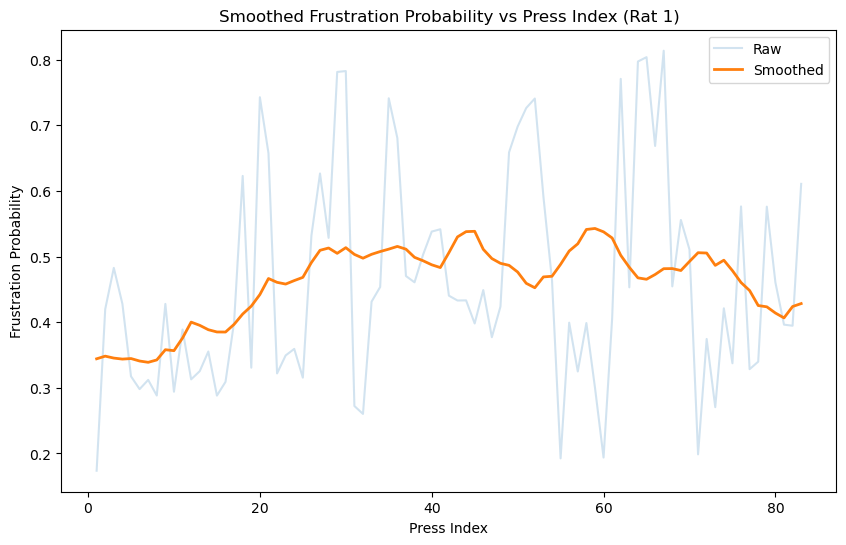

In [ ]:
import matplotlib.pyplot as plt

rat_app = df_app_ML[df_app_ML['id'] == 14].copy()

window = 20  # adjust for smoothing strength

rat_app['frustration_smooth'] = (
    rat_app['frustration_probability']
    .rolling(window=window, center=True, min_periods=1)
    .mean()
)

plt.figure(figsize=(10, 6))

# optional: faint raw data
plt.plot(
    rat_app['seq'],
    rat_app['frustration_probability'],
    alpha=0.2,
    label='Raw'
)

# smoothed line
plt.plot(
    rat_app['seq'],
    rat_app['frustration_smooth'],
    linewidth=2,
    label='Smoothed'
)

plt.title('Smoothed Frustration Probability vs Press Index (Rat 1)')
plt.xlabel('Press Index')
plt.ylabel('Frustration Probability')
plt.legend()
plt.show()

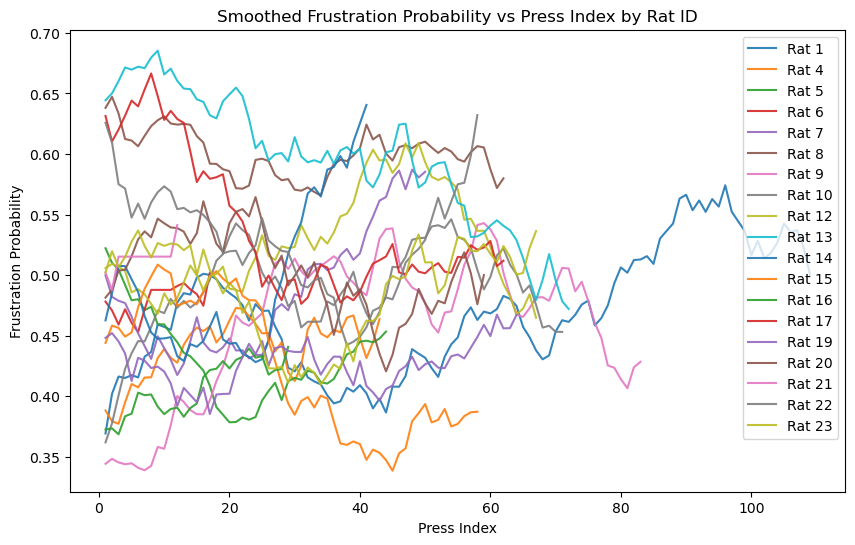

In [262]:
import matplotlib.pyplot as plt

window = 20  # adjust this for more/less smoothing

plt.figure(figsize=(10, 6))

for rat_id, group in df_app_ML.groupby('id'):
    group = group.sort_values('seq').copy()
    group['frustration_smooth'] = (
        group['frustration_probability']
        .rolling(window=window, center=True, min_periods=1)
        .mean()
    )
    first_n = 9999
    plt.plot(
        group['seq'][:first_n],
        group['frustration_smooth'][:first_n],
        label=f'Rat {rat_id}',
        alpha=0.9
    )

plt.title('Smoothed Frustration Probability vs Press Index by Rat ID')
plt.xlabel('Press Index')
plt.ylabel('Frustration Probability')
plt.legend()
plt.show()

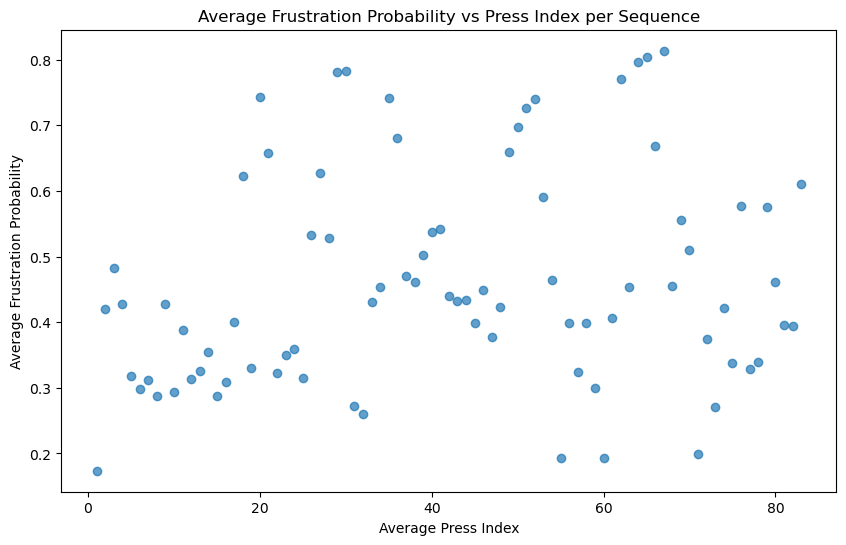

In [239]:
# compute average per seq
seq_avg = (
    rat_app
    .groupby('seq')[['frustration_probability']]
    .mean()
    .reset_index()
)

# scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(seq_avg['seq'], seq_avg['frustration_probability'], alpha=0.7)

plt.title('Average Frustration Probability vs Press Index per Sequence')
plt.xlabel('Average Press Index')
plt.ylabel('Average Frustration Probability')
plt.show()